In [1]:
import os

faiss_path = "/kaggle/input/datasets/abedgaha/my-medical-faiss-db/medical_faiss_db"
donut_path = "/kaggle/input/notebooks/abedgaha/browsingdatasetfordonut/donut_best_model_agha"

print("FAISS Index Exists:", os.path.exists(f"{faiss_path}/index.faiss"))
print("FAISS Texts Exists:", os.path.exists(f"{faiss_path}/texts.npy"))
print("Donut Model Exists:", os.path.exists(donut_path))

FAISS Index Exists: True
FAISS Texts Exists: True
Donut Model Exists: True


In [3]:
!pip install -q faiss-cpu sentence-transformers transformers accelerate pypdf pillow langchain-text-splitters


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 90.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 37.0 MB/s eta 0:00:00


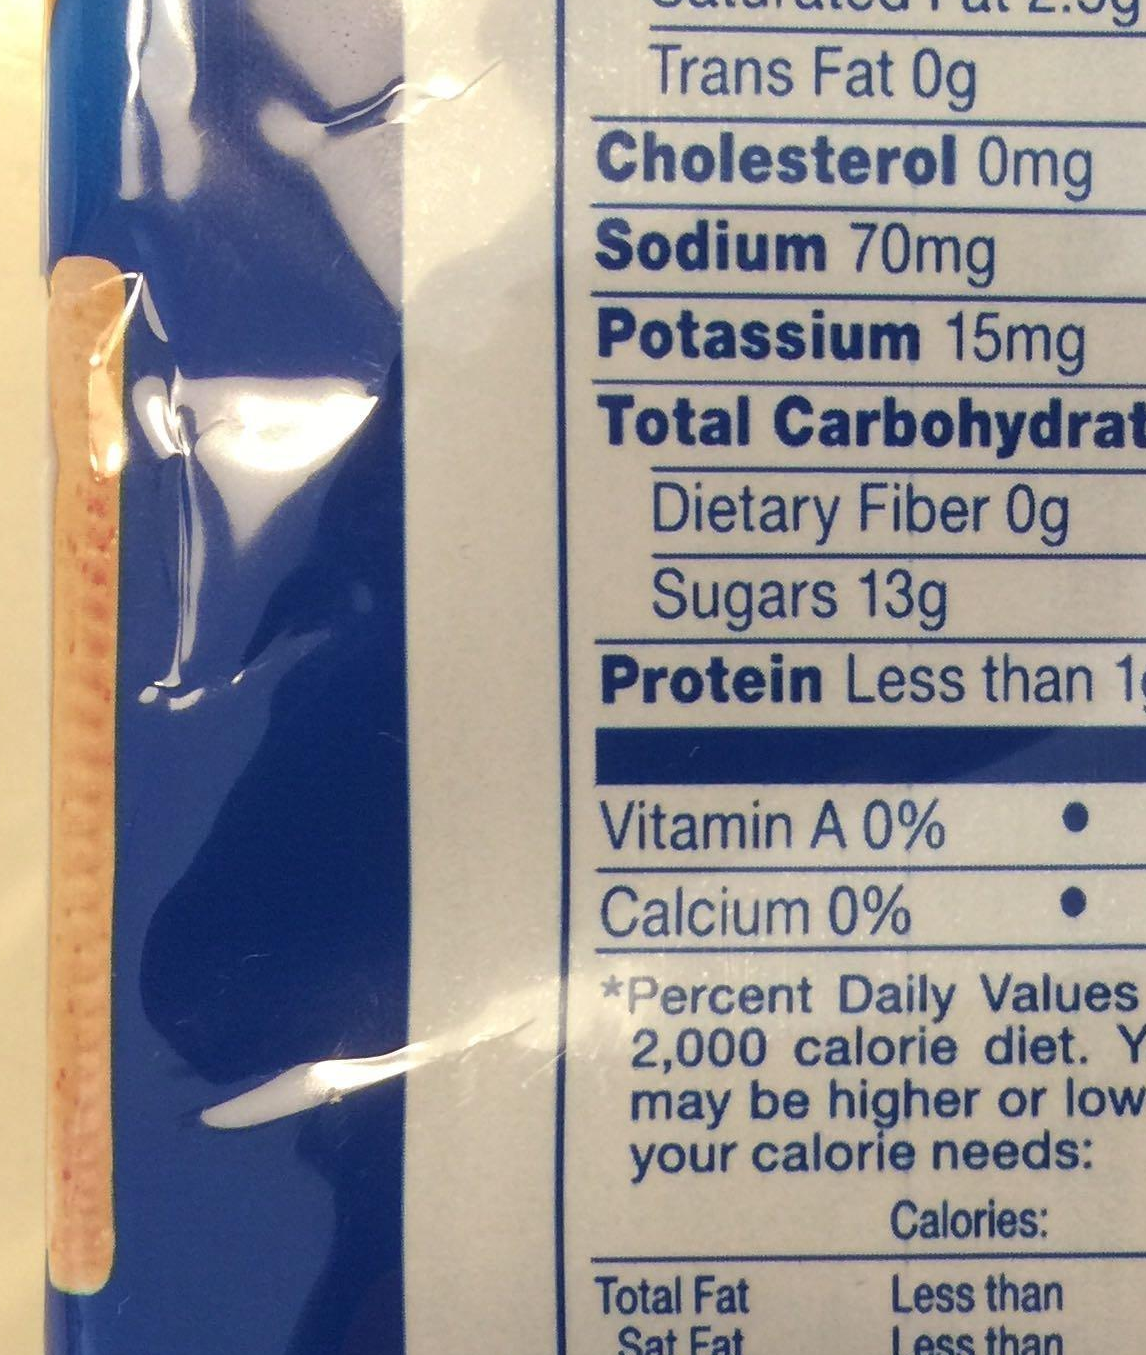

In [6]:
from PIL import Image
from IPython.display import display

img = Image.open( "/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/validation/img_116.png")
display(img)

In [4]:
import os
import json
import faiss
import numpy as np
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DonutProcessor,
    VisionEncoderDecoderModel
)

# ============================================================
# 3) تحميل نموذج Qwen2.5-1.5B-Instruct للتوليد
# ============================================================
model_id = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
qwen_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.float16
)

def generate_recommendation(extracted_values, context_chunks):
    """
    دالة إرسال السياق والقيم إلى Qwen2.5 باستخدام Chat Template المخصص
    """
    context_text = "\n\n".join([f"[Reference {i+1}]:\n{c}" for i, c in enumerate(context_chunks)])
    
    sat = extracted_values.get("saturated_fat", "0")
    na = extracted_values.get("sodium", "0")
    chol = extracted_values.get("cholesterol", "0")

    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert clinical nutritionist AI. Your task is to analyze product nutrition values "
                "against retrieved medical reference texts and provide a clear, concise health recommendation."
            )
        },
        {
            "role": "user",
            "content": f"""
Extracted Nutrition Values from Product Image:
- Saturated Fat: {sat} g
- Sodium: {na} mg
- Cholesterol: {chol} mg

Retrieved Medical Knowledge (Context):
{context_text}

Task:
1) "Extracted values:" → Restate the extracted nutrition values clearly.
2) "Risk explanation:" → Provide a brief explanation of why these values might pose a health risk (e.g., for hypertension/heart disease) based on the medical context.
3) "Recommendations:" → Provide exactly 3 concise, actionable health recommendations.

Do NOT invent information outside the context, and avoid repeating the medical text verbatim.
"""
        }
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        output = qwen_model.generate(
            **inputs,
            max_new_tokens=350,
            temperature=0.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    answer = tokenizer.decode(output[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return answer.strip()

# ============================================================
# 4) تحميل نموذج Donut OCR لاستخراج النصوص من الصورة
# ============================================================
donut_path = "/kaggle/input/notebooks/abedgaha/browsingdatasetfordonut/donut_best_model_agha"
donut_model = VisionEncoderDecoderModel.from_pretrained(donut_path).to("cuda" if torch.cuda.is_available() else "cpu")
donut_processor = DonutProcessor.from_pretrained(donut_path)

def extract_text_from_image(image_path):
    image = Image.open(image_path).convert("RGB")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pixel_values = donut_processor(image, return_tensors="pt").pixel_values.to(device)
    
    output = donut_model.generate(pixel_values, max_length=512)
    text = donut_processor.batch_decode(output, skip_special_tokens=True)[0]
    return text

# ============================================================
# 5) تحميل FAISS DB (المسار الجديد المربوط من Dataset) + نموذج ה-Embedding
# ============================================================
# تم تحديث المسار ليستدعي مخرجات السكريبت الأول المربوطة كـ Dataset
faiss_path = "/kaggle/input/datasets/abedgaha/my-medical-faiss-db/medical_faiss_db"

index = faiss.read_index(f"{faiss_path}/index.faiss")
texts = np.load(f"{faiss_path}/texts.npy", allow_pickle=True)

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def retrieve(query, k=3):
    """
    استرجاع الشرائح الكاملة الناتجة عن التقطيع الذكي بدون قص
    """
    q_emb = embedding_model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(q_emb, k)
    return [texts[i] for i in indices[0]]

# ============================================================
# 6) البايبلاين الكامل للنظام (Image → Donut → FAISS → Qwen)
# ============================================================
def full_pipeline(image_path):
    # 1. OCR: قراءة جدول التغذية من الصورة بواسطة Donut
    extracted_raw = extract_text_from_image(image_path)

    # 2. Parsing: استخراج القيم وتحويلها لبنية JSON
    try:
        parsed_data = json.loads(extracted_raw.replace("'", '"'))
        if "gt_parse" in parsed_data:
            data = parsed_data["gt_parse"]
        else:
            data = parsed_data
    except Exception:
        data = {"saturated_fat": "0", "sodium": "0", "cholesterol": "0"}

    sat = data.get("saturated_fat", "0")
    na = data.get("sodium", "0")
    chol = data.get("cholesterol", "0")

    # 3. RAG Querying: صياغة الاستعلام الدلالي
    query = f"High levels of saturated fat {sat}g, sodium {na}mg, cholesterol {chol}mg health risks and daily limit recommendations"
    
    # 4. Retrieval: استرجاع الشرائح المرجعية الطبية من FAISS (k=3)
    retrieved_chunks = retrieve(query, k=3)

    # 5. Generation: إرسال المعطيات والسياق لـ Qwen2.5 وتوليد النصية
    final_recommendation = generate_recommendation(data, retrieved_chunks)

    return final_recommendation

# ============================================================
# تجربة التشغيل
# ============================================================
result = full_pipeline("/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/validation/img_116.png")
print(result)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Extracted Values:**  
- Saturated Fat: 0.0 g  
- Sodium: 70.0 mg  
- Cholesterol: 0.0 mg  

**Risk Explanation:**  
The extracted values indicate very low levels of saturated fat, sodium, and cholesterol, which are all important nutrients for heart health. However, it's worth noting that even though these values are low, they still fall below the recommended guidelines set by the Dietary Guidelines for Americans. These low levels can lead to a false sense of security about overall dietary habits, as they do not account for other factors like sugar content, fiber, vitamins, minerals, and protein. It's crucial to consider the whole food profile rather than just individual nutrient values when evaluating a diet's impact on health.

**Recommendations:**

1. **Monitor Total Calorie Intake**: Since you're consuming very little saturated fat, sodium, and cholesterol, ensure that your total caloric intake does not exceed what your body requires. This helps maintain a balanced diet without ri